### 모델 개선을 위한 노트북
1. 데이터 가져오기- 데이터 파악- 전처리 과정.

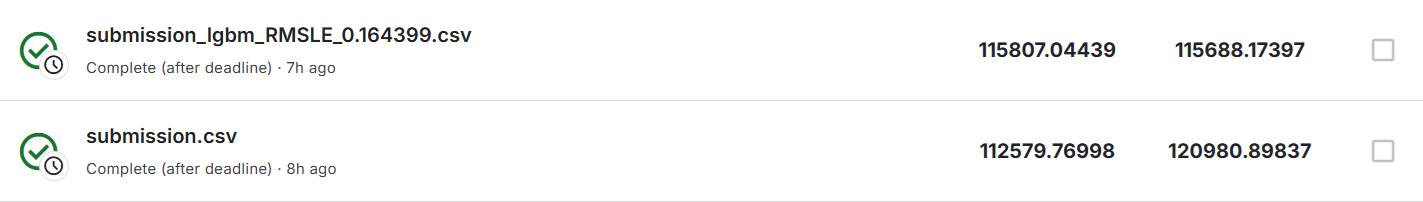

In [1]:
pip install missingno

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


In [5]:
import warnings
warnings.filterwarnings("ignore")

import os
from os.path import join

import pandas as pd
import numpy as np

import missingno as msno

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score
import xgboost as xgb
import lightgbm as lgb

import matplotlib.pyplot as plt
import seaborn as sns    #####경사도 부팅 레그레서 사용 시각화 모듈 불러오기 밑 판다스 님피 분석 모듈도 불러오기

In [6]:
train_data_path =  'train.csv'
test_data_path =  'test.csv'

train = pd.read_csv(train_data_path)
test = pd.read_csv(test_data_path)


In [7]:
train.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,1,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
2,2,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
3,3,20140627T000000,257500.0,3,2.25,1715,6819,2.0,0,0,...,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
4,4,20150115T000000,291850.0,3,1.50,1060,9711,1.0,0,0,...,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711


### 데이터 전처리 
- 날짜를 실수형으로 바꾸기
- 가격을 Y값에 넣고 삭제
- id 콜럼 삭제

In [8]:
train['date'] = train['date'].apply(lambda i: i[:6]).astype(int)
train.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,201410,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,1,201502,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
2,2,201502,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
3,3,201406,257500.0,3,2.25,1715,6819,2.0,0,0,...,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
4,4,201501,291850.0,3,1.50,1060,9711,1.0,0,0,...,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711


In [9]:
y = train['price']
del train['price']

print(train.columns)

Index(['id', 'date', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15'],
      dtype='object')


In [10]:
del train['id']

print(train.columns)

Index(['date', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15'],
      dtype='object')


test 데이터도 동일하게 처리

In [11]:
test['date'] = test['date'].apply(lambda i: i[:6]).astype(int)

del test['id']

print(test.columns)

Index(['date', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15'],
      dtype='object')


In [12]:
y

0         221900.0
1         180000.0
2         510000.0
3         257500.0
4         291850.0
           ...    
15030     610685.0
15031    1007500.0
15032     360000.0
15033     400000.0
15034     325000.0
Name: price, Length: 15035, dtype: float64

0에서 많이 붙어있는 분포를 이루고 있다.

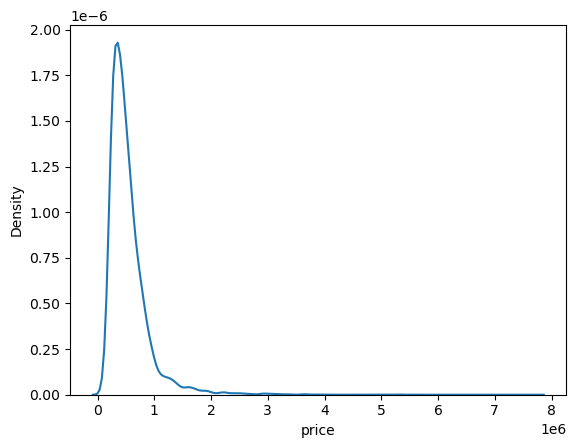

In [13]:
sns.kdeplot(y)
plt.show()

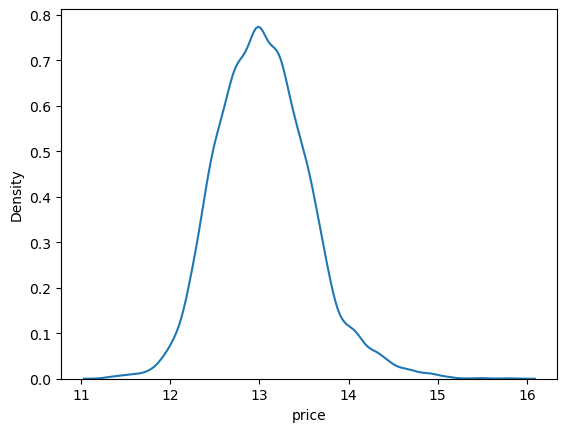

In [14]:
y = np.log1p(y)
sns.kdeplot(y)
plt.show()

로그함수로 처리할 경우 가운데로 분포하게 된다.

In [15]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15035 entries, 0 to 15034
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           15035 non-null  int64  
 1   bedrooms       15035 non-null  int64  
 2   bathrooms      15035 non-null  float64
 3   sqft_living    15035 non-null  int64  
 4   sqft_lot       15035 non-null  int64  
 5   floors         15035 non-null  float64
 6   waterfront     15035 non-null  int64  
 7   view           15035 non-null  int64  
 8   condition      15035 non-null  int64  
 9   grade          15035 non-null  int64  
 10  sqft_above     15035 non-null  int64  
 11  sqft_basement  15035 non-null  int64  
 12  yr_built       15035 non-null  int64  
 13  yr_renovated   15035 non-null  int64  
 14  zipcode        15035 non-null  int64  
 15  lat            15035 non-null  float64
 16  long           15035 non-null  float64
 17  sqft_living15  15035 non-null  int64  
 18  sqft_l

### 2. 손실함수 준비
 RMSE 준비와 데이터셋 나누기

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

def rmse(y_test, y_pred):
    return np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred)))

In [17]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor

In [18]:
random_state=2020        # 하지만 우리는 이렇게 고정값을 세팅해 두겠습니다.

gboost = GradientBoostingRegressor(random_state=random_state)
xgboost = XGBRegressor(random_state=random_state)
lightgbm = LGBMRegressor(random_state=random_state)
rdforest = RandomForestRegressor(random_state=random_state)

models = [gboost, xgboost, lightgbm, rdforest]

In [19]:
df = {}
for model in models:
    # 모델 이름 획득
    model_name = model.__class__.__name__

    # train, test 데이터셋 분리
    # random_state를 사용하여 고정하고 train과 test 셋의 비율은 8:2로 합니다.
    X_train, X_test, y_train, y_test = train_test_split(train, y, random_state=random_state, test_size=0.2)


    # 모델 학습
    model.fit(X_train, y_train)

    # 예측
    y_pred = model.predict(X_test)

    # 예측 결과의 rmse값 저장
    df[model_name] = rmse(y_test, y_pred)

    # data frame에 저장
    score_df = pd.DataFrame(df, index=['RMSE']).T.sort_values('RMSE', ascending=False)

df

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001351 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2298
[LightGBM] [Info] Number of data points in the train set: 12028, number of used features: 19
[LightGBM] [Info] Start training from score 13.047779


{'GradientBoostingRegressor': np.float64(128360.19649691365),
 'XGBRegressor': np.float64(117618.22355411823),
 'LGBMRegressor': np.float64(111920.36735892233),
 'RandomForestRegressor': np.float64(125486.94461618949)}

In [18]:
def get_scores(models, train, y):
    df = {}

    for model in models:
        model_name = model.__class__.__name__

        X_train, X_test, y_train, y_test = train_test_split(train, y, random_state=random_state, test_size=0.2)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        df[model_name] = rmse(y_test, y_pred)
        score_df = pd.DataFrame(df, index=['RMSE']).T.sort_values('RMSE', ascending=False)

    return score_df

모델과 데이터셋이 준비가 되었습니다.

### 3. 하이퍼 파라미터 튜닝 해보기

In [20]:
from sklearn.model_selection import GridSearchCV

먼저 GridSearchCV에 입력되는 인자들은 다음과 같다.

param_grid : 탐색할 파라미터의 종류 (딕셔너리로 입력)  
scoring : 모델의 성능을 평가할 지표  
cv : cross validation을 수행하기 위해 train 데이터셋을 나누는 조각의 개수  
verbose : 그리드 탐색을 진행하면서 진행 과정을 출력해서 보여줄 메세지의 양 (숫자가 클수록 더 많은 메세지를 출력합니다.)  
n_jobs : 그리드 탐색을 진행하면서 사용할 CPU의 개수  


In [24]:
param_grid = {
    'num_leaves': [31, 63],
    'min_child_samples': [10, 20, 30],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [150, 200]

}
model = LGBMRegressor(random_state=random_state)

In [25]:
grid_model = GridSearchCV(model, param_grid=param_grid, \
                        scoring='neg_mean_squared_error', \
                        cv=5, verbose=1, n_jobs=5)

grid_model.fit(train, y)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.031331 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2298
[LightGBM] [Info] Number of data points in the train set: 12028, number of used features: 19
[LightGBM] [Info] Start training from score 13.035255
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007884 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2331
[LightGBM] [Info] Number of data points in the train set: 12028, number of used features: 19
[LightGBM] [Info] Start training from score 13.051670
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012468 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bi

,estimator,LGBMRegressor...om_state=2020)
,param_grid,"{'learning_rate': [0.05, 0.1], 'min_child_samples': [10, 20, ...], 'n_estimators': [500, 1000], 'num_leaves': [31, 63]}"
,scoring,'neg_mean_squared_error'
,n_jobs,5
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,boosting_type,'gbdt'


In [26]:
grid_model.cv_results_

{'mean_fit_time': array([ 5.98885951,  9.51230168, 11.76479459, 16.89308357,  6.01203251,
         9.3932961 , 11.19223385, 17.09648972,  6.0565877 ,  8.78336282,
        11.14498258, 18.49618082,  5.59586101,  8.51027055, 10.24098806,
        15.99963613,  5.69828906,  8.84677   ,  9.85940351, 16.1057723 ,
         5.20641041,  8.90458856, 10.45694084, 16.36251831]),
 'std_fit_time': array([0.30788853, 0.6059498 , 0.59260278, 1.32263788, 0.42554108,
        0.38984179, 0.49837832, 0.68831007, 0.26740622, 0.44655236,
        0.47790956, 1.36228557, 0.19903774, 0.45473828, 0.49954146,
        1.0635233 , 0.35037996, 0.57097962, 0.86271776, 0.95057521,
        0.4255875 , 0.36017062, 0.42653098, 1.41770399]),
 'mean_score_time': array([0.57290139, 0.75040669, 1.61224356, 2.0836328 , 0.58095446,
        0.85242949, 1.64853458, 2.10872922, 0.58671083, 1.03007073,
        1.76008191, 2.51983724, 0.40821257, 0.65315804, 1.38455391,
        1.78104267, 0.53514857, 0.79230204, 1.26409059, 2.16

In [27]:
params = grid_model.cv_results_['params']
params

[{'learning_rate': 0.05,
  'min_child_samples': 10,
  'n_estimators': 500,
  'num_leaves': 31},
 {'learning_rate': 0.05,
  'min_child_samples': 10,
  'n_estimators': 500,
  'num_leaves': 63},
 {'learning_rate': 0.05,
  'min_child_samples': 10,
  'n_estimators': 1000,
  'num_leaves': 31},
 {'learning_rate': 0.05,
  'min_child_samples': 10,
  'n_estimators': 1000,
  'num_leaves': 63},
 {'learning_rate': 0.05,
  'min_child_samples': 20,
  'n_estimators': 500,
  'num_leaves': 31},
 {'learning_rate': 0.05,
  'min_child_samples': 20,
  'n_estimators': 500,
  'num_leaves': 63},
 {'learning_rate': 0.05,
  'min_child_samples': 20,
  'n_estimators': 1000,
  'num_leaves': 31},
 {'learning_rate': 0.05,
  'min_child_samples': 20,
  'n_estimators': 1000,
  'num_leaves': 63},
 {'learning_rate': 0.05,
  'min_child_samples': 30,
  'n_estimators': 500,
  'num_leaves': 31},
 {'learning_rate': 0.05,
  'min_child_samples': 30,
  'n_estimators': 500,
  'num_leaves': 63},
 {'learning_rate': 0.05,
  'min_chil

In [28]:
score = grid_model.cv_results_['mean_test_score']
score

array([-0.0261175 , -0.02627194, -0.02609886, -0.02659609, -0.0260543 ,
       -0.02618818, -0.02604733, -0.02663237, -0.02596058, -0.02631344,
       -0.02602522, -0.0268165 , -0.02637929, -0.02678222, -0.02668161,
       -0.02710242, -0.0263397 , -0.02718662, -0.02676658, -0.02771017,
       -0.02641645, -0.02732676, -0.02693499, -0.02789002])

In [29]:
results = pd.DataFrame(params)
results['score'] = score

results

,learning_rate,min_child_samples,n_estimators,num_leaves,score
0,0.05,10,500,31,-0.026117
1,0.05,10,500,63,-0.026272
2,0.05,10,1000,31,-0.026099
3,0.05,10,1000,63,-0.026596
4,0.05,20,500,31,-0.026054
5,0.05,20,500,63,-0.026188
6,0.05,20,1000,31,-0.026047
7,0.05,20,1000,63,-0.026632
8,0.05,30,500,31,-0.025961
9,0.05,30,500,63,-0.026313


In [30]:
results['RMSE'] = np.sqrt(-1 * results['score'])
results

,learning_rate,min_child_samples,n_estimators,num_leaves,score,RMSE
0,0.05,10,500,31,-0.026117,0.161609
1,0.05,10,500,63,-0.026272,0.162086
2,0.05,10,1000,31,-0.026099,0.161551
3,0.05,10,1000,63,-0.026596,0.163083
4,0.05,20,500,31,-0.026054,0.161413
5,0.05,20,500,63,-0.026188,0.161828
6,0.05,20,1000,31,-0.026047,0.161392
7,0.05,20,1000,63,-0.026632,0.163194
8,0.05,30,500,31,-0.025961,0.161123
9,0.05,30,500,63,-0.026313,0.162214


In [31]:
results = results.rename(columns={'RMSE': 'RMSLE'})
results

results = results.sort_values('RMSLE')
results

,max_depth,n_estimators,score,RMSLE
3,10,100,-0.027027,0.164399
2,10,50,-0.029177,0.170814
1,1,100,-0.055020,0.234564
0,1,50,-0.073394,0.270914


In [31]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [1, 10],
}

model = LGBMRegressor(random_state=random_state)
my_GridSearch= GridSearchCV(model, param_grid, verbose=2, n_jobs=5)

In [32]:
model = LGBMRegressor(max_depth=10, n_estimators=100, random_state=random_state)
model.fit(train, y)
prediction = model.predict(test)
prediction

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003202 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2338
[LightGBM] [Info] Number of data points in the train set: 15035, number of used features: 19
[LightGBM] [Info] Start training from score 13.048122


array([13.13580793, 13.08051399, 14.11202067, ..., 13.01592878,
       12.69894979, 12.96297768], shape=(6468,))

In [33]:
prediction = np.expm1(prediction)
prediction

array([ 506766.66784595,  479506.10405112, 1345155.15609376, ...,
        449515.92243642,  327402.87855805,  426332.71354302],
      shape=(6468,))

In [34]:
submission_path = 'sample_submission.csv'
submission = pd.read_csv(submission_path)
submission.head()

,id,price
0,15035,100000
1,15036,100000
2,15037,100000
3,15038,100000
4,15039,100000


In [35]:
submission['price'] = prediction
submission.head()

,id,price
0,15035,5.067667e+05
1,15036,4.795061e+05
2,15037,1.345155e+06
3,15038,3.122579e+05
4,15039,3.338645e+05


In [36]:
submission_csv_path = 'submission_{}_RMSLE_{}.csv'.format('lgbm', '0.164399')
submission.to_csv(submission_csv_path, index=False)
print(submission_csv_path)

submission_lgbm_RMSLE_0.164399.csv
